In [2]:
#Imports

In [3]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
from autogluon.multimodal import MultiModalPredictor
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='pkg_resources')

**#Data Preparation**

In [4]:
df = pd.read_csv(
    '/content/Review-Guardian/data/processed/labeled_reviews.csv'
)

df = df.dropna(subset=['content_clean', 'pseudo_label'])
df['pseudo_label'] = df['pseudo_label'].astype(int)

df = df[['content_clean', 'pseudo_label']].rename(columns={'content_clean': 'text', 'pseudo_label': 'label'})

train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

print(f"Train: {len(train_df)} | Test: {len(test_df)}")
print("Label balance (train):")
print(train_df['label'].value_counts(normalize=True))

Train: 4985 | Test: 1247
Label balance (train):
label
0    0.879238
1    0.120762
Name: proportion, dtype: float64


**Fine-tune with AutoGluon MultiModal**

Choices:
- `eval_metric='f1'` optimizes for the fake class instead of raw accuracy, which is what you actually care about given the recall problem.
- `presets='best_quality'` tries multiple backbones and ensembles them but can be slow on Kaggle. If you're short on time/GPU quota, switch to `presets='medium_quality'` first to sanity-check the pipeline, then rerun with `best_quality`.
- `time_limit` is in seconds — set it based on your Kaggle session budget so it doesn't get cut off mid-training.

**Compute + storage note:** this trained for the full 3600s (1hr) time limit on a Kaggle GPU. AutoGluon MultiModal checkpoints are large (often several GB), so this folder should be added to `.gitignore` -- do not try to commit it to the repo directly.

In [5]:
predictor = MultiModalPredictor(
    label='label',
    problem_type='binary',
    eval_metric='f1',
    path='/content/Review-Guardian/models/autogluon_reviewguardian'
    # to this path during .fit(), so this one-line fix is the entire save fix for this notebook
)

predictor.fit(
    train_data=train_df,
    presets='medium_quality',
    time_limit=3600,
    hyperparameters={"env.num_gpus": 1},
)

=================== System Info ===================
AutoGluon Version:  1.6.1
Python Version:     3.13.15
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Thu Apr 30 18:17:14 UTC 2026
CPU Count:          2
Pytorch Version:    2.11.0+cu128
CUDA Version:       12.8
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       9.23 GB / 12.67 GB (72.8%)
Disk Space Avail:   64.44 GB / 112.64 GB (57.2%)

AutoMM starts to create your model. ✨✨✨

To track the learning progress, you can open a terminal and launch Tensorboard:
    ```shell
    # Assume you have installed tensorboard
    tensorboard --logdir /content/Review-Guardian/models/autogluon_reviewguardian
    ```

INFO: Seed set to 0


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 54.2MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

AutoMM has created your model. 🎉🎉🎉

To load the model, use the code below:
    ```python
    from autogluon.multimodal import MultiModalPredictor
    predictor = MultiModalPredictor.load("/content/Review-Guardian/models/autogluon_reviewguardian")
    ```

If you are not satisfied with the model, try to increase the training time, 
adjust the hyperparameters (https://auto.gluon.ai/stable/tutorials/multimodal/advanced_topics/customization.html),
or post issues on GitHub (https://github.com/autogluon/autogluon/issues).




**Evaluation Harness**

Same harness as before, so DistilBERT and AutoGluon are scored the exact same way and are directly comparable.

In [6]:
def evaluate_model(y_true, y_pred, y_proba=None, model_name='Model'):
    print(f"=== {model_name} ===")
    print(classification_report(y_true, y_pred))
    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix:\n", cm)
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_true, y_proba)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc(fpr, tpr):.2f})")
        plt.plot([0,1],[0,1],'k--')
        plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
        plt.legend(); plt.title('ROC Curve')


**Running AutoGluon through the harness**

INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

=== AutoGluon MultiModal ===
              precision    recall  f1-score   support

           0       0.90      0.85      0.87      1096
           1       0.23      0.32      0.27       151

    accuracy                           0.79      1247
   macro avg       0.57      0.59      0.57      1247
weighted avg       0.82      0.79      0.80      1247

Confusion matrix:
 [[931 165]
 [102  49]]


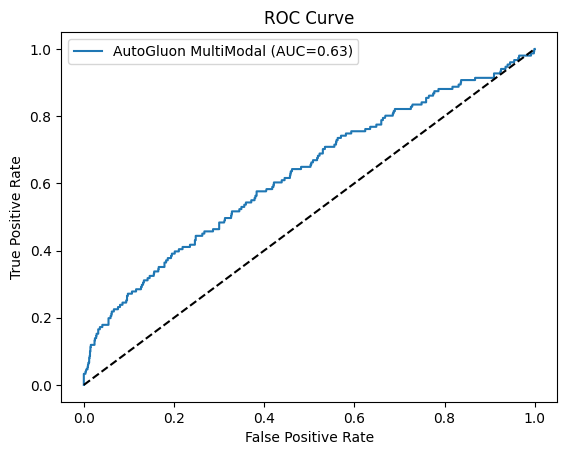

In [8]:
y_pred = predictor.predict(test_df)
y_proba_df = predictor.predict_proba(test_df)   # DataFrame with columns [0, 1]
y_proba = y_proba_df[1].values                  # probability of the "fake" class

evaluate_model(test_df['label'], y_pred, y_proba, 'AutoGluon MultiModal')
plt.show()